# MBTI Personality Prediction
**Project Goal:** The project aims to predict a person's MBTI personality type based on their text posts using Natural Language Processing (NLP) and machine learning.

**Steps**:

1.   Data Preparation:
  Imported the MBTI dataset (mbti_1.csv).
  Cleaned the text data by removing links and MBTI type mentions.
2.  Data Preprocessing:
  Converted MBTI types into numerical labels using Label Encoding.
Split the data into training and validation sets.
Tokenized the text data using the distilbert-base-uncased tokenizer from Hugging Face Transformers.
3. Model Building and Training:
Used a pre-trained DistilBERT model (distilbert-base-uncased) for sequence classification and fine-tuned it for MBTI prediction.
Trained the model using the Hugging Face Trainer with specified hyperparameters.
Evaluated the model's performance using accuracy as the metric.
4. Model Evaluation and Visualization:
Plotted the validation accuracy and loss over epochs to visualize the training process.
Generated a classification report and confusion matrix to assess the model's performance on different MBTI types.
Visualized per-class precision, recall, and F1-score using a bar chart.
5. Binary MBTI Trait Prediction:
Extracted binary features for each MBTI trait (I/E, N/S, T/F, J/P).
Trained separate models for each trait using the BERT model.
Evaluated the accuracy of each model.
Generated classification reports and confusion matrices for each trait.
Compared the accuracy of all binary trait models.

**Key Libraries:**

pandas, re, nltk, sklearn, transformers, datasets, evaluate, torch, matplotlib, seaborn

In [3]:
!pip install nltk==3.8.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.4 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
textblob 0.19.0 requires nltk>=3.9, but you have nltk 3.8.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.8/385.8 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Data Preparation and 2. Preprocessing

In [ ]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
mbti_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mbti_1.csv')
mbti_data.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [ ]:
def remove_links(text):
  return re.sub(r'http\S+', '', text)

mbti_data['posts'] = mbti_data['posts'].apply(remove_links)
mbti_data.head()

,type,posts
0,INFJ,' and intj moments sportscenter not top ten...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,"'Good one _____ course, to which I say I k..."
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [ ]:
def remove_mbti_mentions(text):
  mbti_types = ["INFP", "INFJ", "INTP", "INTJ", "ENTP", "ENTJ", "ENFP", "ENFJ",
                "ISFP", "ISFJ", "ISTP", "ISTJ", "ESFP", "ESFJ", "ESTP", "ESTJ"]

  pattern = r'\b.?(?:' + '|'.join(mbti_types) + r')s?.?\b'
  return re.sub(pattern, '', text, flags=re.IGNORECASE)

mbti_data['posts'] = mbti_data['posts'].apply(remove_mbti_mentions)
mbti_data.head()

,type,posts
0,INFJ,' andmoments sportscenter not top ten plays...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,"'Good one _____ course, to which I say I k..."
3,INTJ,"'Dear, I enjoyed our conversation the other ..."
4,ENTJ,'You're fired.|||That's another silly misconce...


# 3. Model Building and Training

In [ ]:
!pip install -q transformers datasets evaluate scikit-learn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 23.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12

In [ ]:
!pip uninstall -y transformers huggingface_hub accelerate
!pip install --no-cache-dir transformers \
                             huggingface_hub \
                             accelerate \
                             datasets evaluate scikit-learn joblib

!pip install hf_xet

Found existing installation: transformers 4.51.3
Uninstalling transformers-4.51.3:
  Successfully uninstalled transformers-4.51.3
Found existing installation: huggingface-hub 0.30.2
Uninstalling huggingface-hub-0.30.2:
  Successfully uninstalled huggingface-hub-0.30.2
Found existing installation: accelerate 1.6.0
Uninstalling accelerate-1.6.0:
  Successfully uninstalled accelerate-1.6.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.4/481.4 kB 222.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 212.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 183.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 170.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 248.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.

This is the first model we created using the Distilbert model, which is smaller. Using the BERT model originally caused overfitting issues, so we changed the model used to the Distilbert model which is smaller. This prevented the model from memorizing the data, works faster, and our data only contains 8,600 entries so BERT is not technically necessary.

In [ ]:
print(mbti_data["type"].value_counts())   # See class balance
print(mbti_data.isna().sum())             # Make sure no NaNs in posts / type

# 3.  Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
mbti_data["label"] = le.fit_transform(mbti_data["type"])   # 0-15

# 4.  Train / validation split
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    mbti_data[["posts", "label"]],
    test_size=0.10,
    stratify=mbti_data["label"],
    random_state=42
)

# 5.  Hugging Face Datasets & tokeniser

from datasets import Dataset
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))

from transformers import AutoTokenizer
#MODEL_NAME = "bert-base-uncased" larger model
MODEL_NAME = "distilbert-base-uncased"  #smaller model, better to prevent overfitting, will not memorize data and our data set is under 10,000 entries
MAX_LEN = 256

tok = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tok(batch["posts"], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tokenize, batched=True, remove_columns=["posts"])
val_ds   = val_ds.map(tokenize,   batched=True, remove_columns=["posts"])

# 6.  Build the model

from transformers import AutoModelForSequenceClassification
num_labels = len(le.classes_)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)



type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64
type     0
posts    0
dtype: int64


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/7807 [00:00<?, ? examples/s]

Map:   0%|          | 0/868 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:

from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import evaluate, torch

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=-1)
    return accuracy.compute(predictions=preds, references=labels)

args = TrainingArguments(
    eval_strategy="epoch",
    save_strategy="epoch",
    output_dir="bert_mbti",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    num_train_epochs=5,
    #evaluation_strategy="epoch",
    #save_strategy="epoch",
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=torch.cuda.is_available(),    # mixed precision on GPU
    logging_steps=50,
    report_to = "none"
)
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tok,
    data_collator=DataCollatorWithPadding(tok),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  #will stop training if validation accuracy doesn't improve for 2 epochs
)

# 8.  Train & evaluate

trainer.train()
print(trainer.evaluate())

# 9.  Save artefacts
trainer.save_model("bert_mbti/best")
tok.save_pretrained("bert_mbti/best")

import joblib
joblib.dump(le, "bert_mbti/label_encoder.pkl")

#
# 10.  Handy inference function
def predict_mbti(raw_text: str, model_path="bert_mbti/best"):
    tok   = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    le    = joblib.load(f"{model_path}/../label_encoder.pkl")

    inputs = tok(raw_text, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred = logits.argmax(-1).item()
    return le.inverse_transform([pred])[0]

# Quick test
#print(predict_mbti("I love abstract ideas and strategic planning."))  # → e.g. "INTJ

<ipython-input-10-c48b18dfdfb1>:30: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,2.221700,2.220353,0.224654
2,2.124900,2.199262,0.251152
3,1.795000,2.175726,0.267281
4,1.631400,2.297166,0.256912
5,1.474200,2.341300,0.250000


{'eval_loss': 2.1757264137268066, 'eval_accuracy': 0.2672811059907834, 'eval_runtime': 2.0762, 'eval_samples_per_second': 418.065, 'eval_steps_per_second': 52.499, 'epoch': 5.0}


In [ ]:
trainer.state.log_history  # Shows list of logged metrics


[{'loss': 2.451,
  'grad_norm': 4.477431297302246,
  'learning_rate': 1.9799180327868853e-05,
  'epoch': 0.05122950819672131,
  'step': 50},
 {'loss': 2.3053,
  'grad_norm': 4.720027923583984,
  'learning_rate': 1.9594262295081968e-05,
  'epoch': 0.10245901639344263,
  'step': 100},
 {'loss': 2.3152,
  'grad_norm': 5.4640607833862305,
  'learning_rate': 1.9389344262295083e-05,
  'epoch': 0.15368852459016394,
  'step': 150},
 {'loss': 2.2928,
  'grad_norm': 6.938680648803711,
  'learning_rate': 1.91844262295082e-05,
  'epoch': 0.20491803278688525,
  'step': 200},
 {'loss': 2.2486,
  'grad_norm': 5.328064918518066,
  'learning_rate': 1.898360655737705e-05,
  'epoch': 0.25614754098360654,
  'step': 250},
 {'loss': 2.2751,
  'grad_norm': 4.2119574546813965,
  'learning_rate': 1.8778688524590165e-05,
  'epoch': 0.3073770491803279,
  'step': 300},
 {'loss': 2.2206,
  'grad_norm': 6.266769886016846,
  'learning_rate': 1.857377049180328e-05,
  'epoch': 0.35860655737704916,
  'step': 350},
 {'l

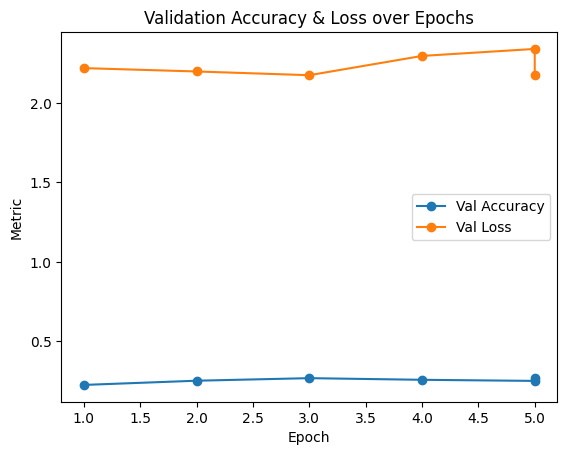

In [ ]:
# start fresh
import matplotlib.pyplot as plt
log_df = pd.DataFrame(trainer.state.log_history)
eval_df = log_df.dropna(subset=["eval_loss", "eval_accuracy"])
plt.plot(eval_df["epoch"], eval_df["eval_accuracy"], marker="o", label="Val Accuracy")
plt.plot(eval_df["epoch"], eval_df["eval_loss"],       marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.title("Validation Accuracy & Loss over Epochs")
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions
preds_output = trainer.predict(val_ds)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

print(classification_report(y_true, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        19
        ENFP       0.17      0.10      0.13        68
        ENTJ       0.00      0.00      0.00        23
        ENTP       0.18      0.12      0.14        69
        ESFJ       0.00      0.00      0.00         4
        ESFP       0.00      0.00      0.00         5
        ESTJ       0.00      0.00      0.00         4
        ESTP       0.00      0.00      0.00         9
        INFJ       0.26      0.29      0.27       147
        INFP       0.28      0.50      0.36       183
        INTJ       0.23      0.14      0.17       109
        INTP       0.30      0.50      0.38       130
        ISFJ       0.00      0.00      0.00        17
        ISFP       0.00      0.00      0.00        27
        ISTJ       0.00      0.00      0.00        20
        ISTP       0.21      0.12      0.15        34

    accuracy                           0.27       868
   macro avg       0.10   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


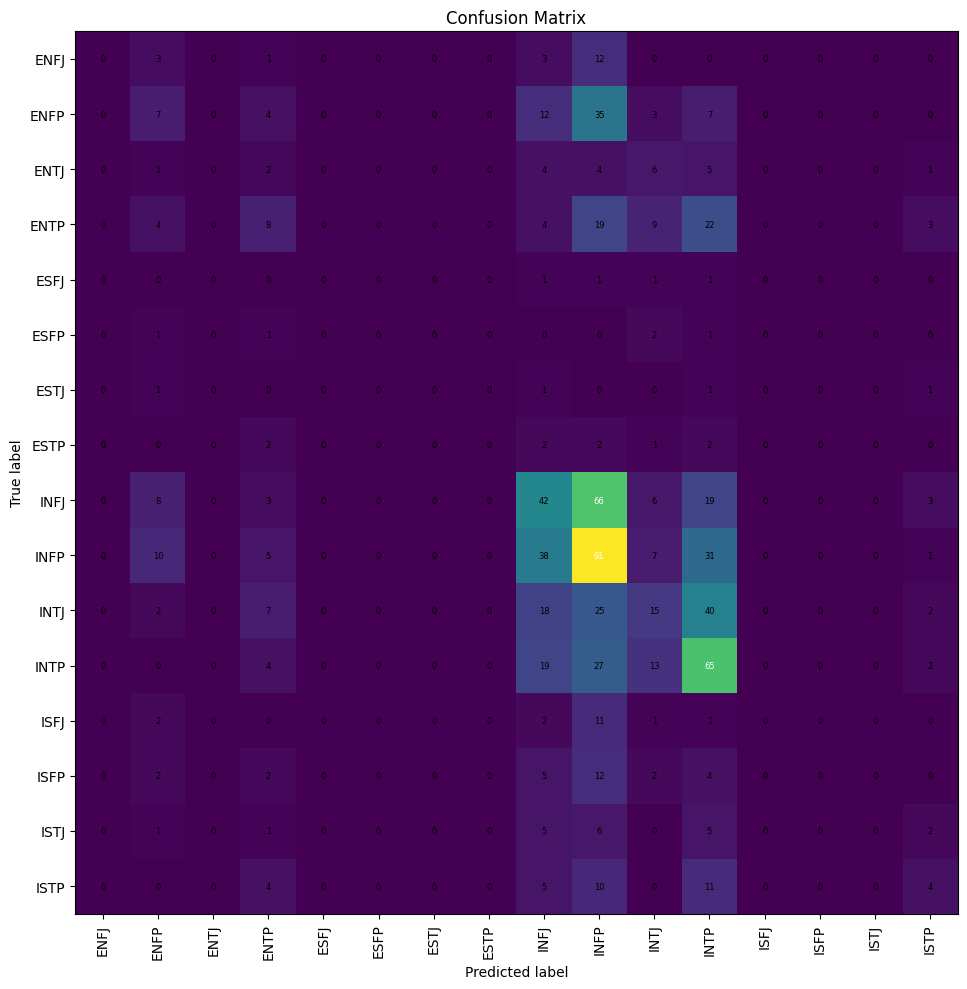

In [ ]:
# confusion matrix heat map
import itertools


# 1. Compute
cm = confusion_matrix(y_true, y_pred)

# 2. Plot
plt.figure(figsize=(12,10))
plt.imshow(cm, interpolation='nearest')       # default colormap
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

# 3. Tick labels
classes = le.classes_
plt.xticks(np.arange(len(classes)), classes, rotation=90)
plt.yticks(np.arange(len(classes)), classes)

# 4. Annotate each cell with its count
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j, i, cm[i, j],
        ha="center", va="center",
        color="white" if cm[i, j] > thresh else "black",
        fontsize=6
    )

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


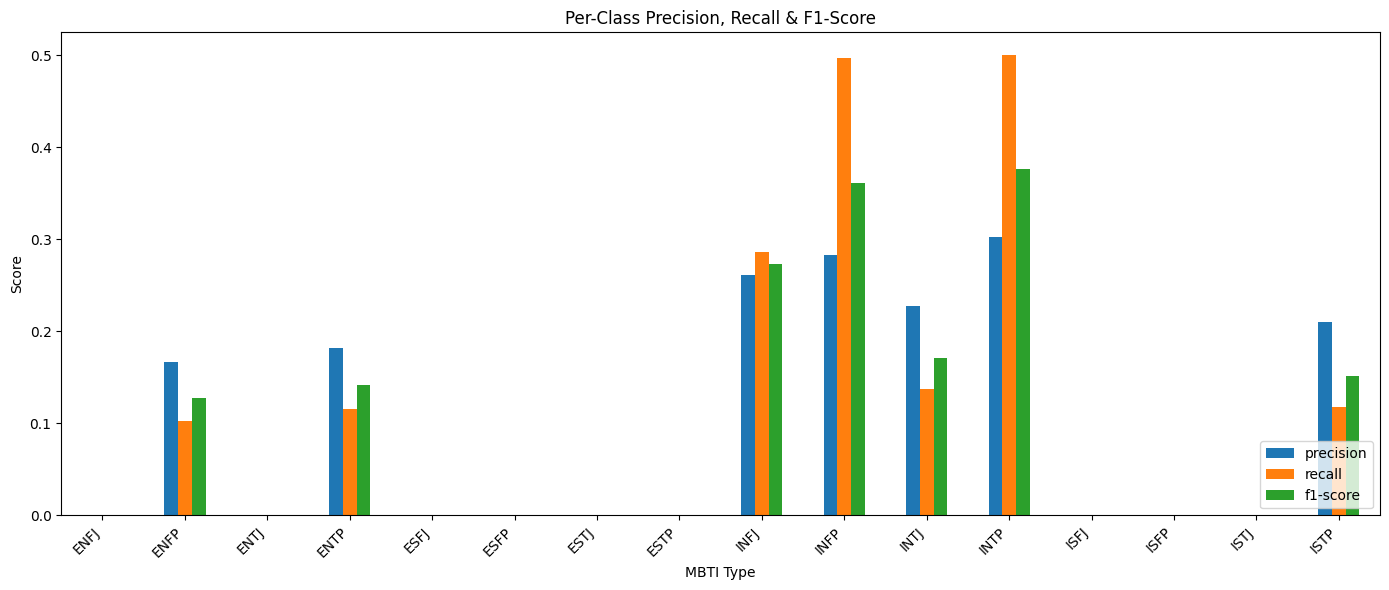

In [ ]:
#Precision/Recall/F1
from sklearn.metrics import classification_report

# 1. Get dict form of the report
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

# 2. Build DataFrame and drop the “accuracy”/“macro avg”/“weighted avg” rows if you like
report_df = pd.DataFrame(report_dict).T
metrics_df = report_df.loc[le.classes_, ["precision", "recall", "f1-score"]]

# 3. Plot
metrics_df.plot(kind="bar", figsize=(14,6))
plt.title("Per-Class Precision, Recall & F1-Score")
plt.xlabel("MBTI Type")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
mbti_data1 = mbti_data.copy()

In [ ]:
# Extract I/E, N/S, T/F, J/P from MBTI types and create separate columns
mbti_data1['I/E'] = mbti_data1['type'].apply(lambda x: 1 if x[0] == 'I' else 0)  # I/E
mbti_data1['N/S'] = mbti_data1['type'].apply(lambda x: 1 if x[1] == 'N' else 0)  # N/S
mbti_data1['T/F'] = mbti_data1['type'].apply(lambda x: 1 if x[2] == 'T' else 0)  # T/F
mbti_data1['J/P'] = mbti_data1['type'].apply(lambda x: 1 if x[3] == 'J' else 0)  # J/P


In [ ]:
mbti_data1.head()

,type,posts,label,I/E,N/S,T/F,J/P
0,INFJ,' andmoments sportscenter not top ten plays...,8,1,1,0,1
1,ENTP,'I'm finding the lack of me in these posts ver...,3,0,1,1,0
2,INTP,"'Good one _____ course, to which I say I k...",11,1,1,1,0
3,INTJ,"'Dear, I enjoyed our conversation the other ...",10,1,1,1,1
4,ENTJ,'You're fired.|||That's another silly misconce...,2,0,1,1,1


In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate

# Load tokenizer
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 256
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# STEP 1: Extract binary MBTI columns
mbti_data1['I/E'] = mbti_data1['type'].apply(lambda x: 1 if x[0] == 'I' else 0)
mbti_data1['N/S'] = mbti_data1['type'].apply(lambda x: 1 if x[1] == 'N' else 0)
mbti_data1['T/F'] = mbti_data1['type'].apply(lambda x: 1 if x[2] == 'T' else 0)
mbti_data1['J/P'] = mbti_data1['type'].apply(lambda x: 1 if x[3] == 'J' else 0)

# STEP 2: Function to create tokenized train and val datasets
def prepare_mbti_binary_datasets(df, label_col, test_size=0.1):
    train_df, val_df = train_test_split(df[['posts', label_col]], test_size=test_size, stratify=df[label_col], random_state=42)

    train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
    val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))

    def tokenize(batch):
        return tokenizer(batch["posts"], truncation=True, padding="max_length", max_length=MAX_LEN)

    train_ds = train_ds.map(tokenize, batched=True, remove_columns=["posts"])
    val_ds = val_ds.map(tokenize, batched=True, remove_columns=["posts"])

    train_ds = train_ds.rename_column(label_col, "labels")
    val_ds = val_ds.rename_column(label_col, "labels")

    train_ds.set_format("torch")
    val_ds.set_format("torch")

    return train_ds, val_ds

# STEP 3: Model training function
def train_model(train_dataset, val_dataset, task_name, num_labels=2):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

    args = TrainingArguments(
        output_dir=f"bert_{task_name}",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        learning_rate=2e-5,
        logging_dir=f"logs_{task_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        report_to="none",
    )

    accuracy = evaluate.load("accuracy")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = torch.argmax(torch.tensor(logits), dim=-1)
        return accuracy.compute(predictions=preds, references=labels)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    return trainer

# STEP 4: Prepare datasets for all 4 MBTI traits
train_ds_ie, val_ds_ie = prepare_mbti_binary_datasets(mbti_data1, "I/E")
train_ds_ns, val_ds_ns = prepare_mbti_binary_datasets(mbti_data1, "N/S")
train_ds_tf, val_ds_tf = prepare_mbti_binary_datasets(mbti_data1, "T/F")
train_ds_jp, val_ds_jp = prepare_mbti_binary_datasets(mbti_data1, "J/P")

# STEP 5: Train models
trainer_ie = train_model(train_ds_ie, val_ds_ie, "IE")
trainer_ns = train_model(train_ds_ns, val_ds_ns, "NS")
trainer_tf = train_model(train_ds_tf, val_ds_tf, "TF")
trainer_jp = train_model(train_ds_jp, val_ds_jp, "JP")



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/7807 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.410500,0.399140,0.861751
2,0.391200,0.392587,0.860599
3,0.323000,0.464935,0.832949


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.654800,0.602228,0.679724
2,0.528500,0.598373,0.716590
3,0.351700,0.777508,0.706221


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.677500,0.667828,0.603687
2,0.657400,0.659381,0.611751
3,0.562900,0.735919,0.599078



Classification Report for Introvert (I):
                   precision    recall  f1-score   support

Not Introvert (I)       0.00      0.00      0.00       200
    Introvert (I)       0.77      1.00      0.87       668

         accuracy                           0.77       868
        macro avg       0.38      0.50      0.43       868
     weighted avg       0.59      0.77      0.67       868



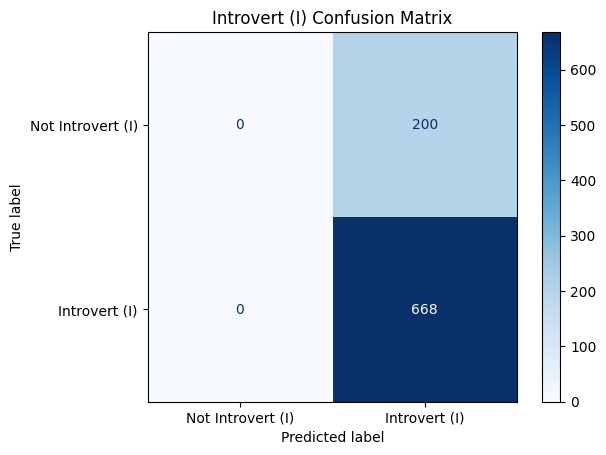


Classification Report for Intuitive (N):
                   precision    recall  f1-score   support

Not Intuitive (N)       0.00      0.00      0.00       120
    Intuitive (N)       0.86      1.00      0.93       748

         accuracy                           0.86       868
        macro avg       0.43      0.50      0.46       868
     weighted avg       0.74      0.86      0.80       868



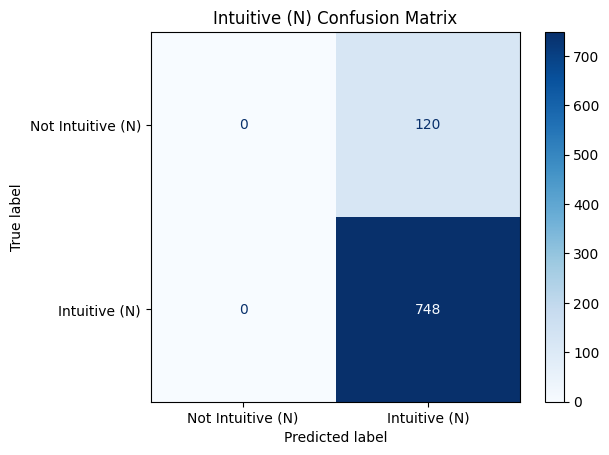


Classification Report for Thinking (T):
                  precision    recall  f1-score   support

Not Thinking (T)       0.75      0.72      0.73       470
    Thinking (T)       0.68      0.71      0.70       398

        accuracy                           0.72       868
       macro avg       0.72      0.72      0.72       868
    weighted avg       0.72      0.72      0.72       868



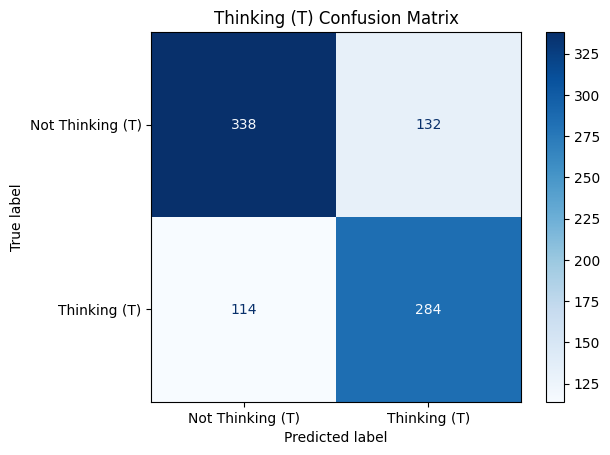


Classification Report for Judging (J):
                 precision    recall  f1-score   support

Not Judging (J)       0.66      0.72      0.69       524
    Judging (J)       0.51      0.44      0.47       344

       accuracy                           0.61       868
      macro avg       0.59      0.58      0.58       868
   weighted avg       0.60      0.61      0.61       868



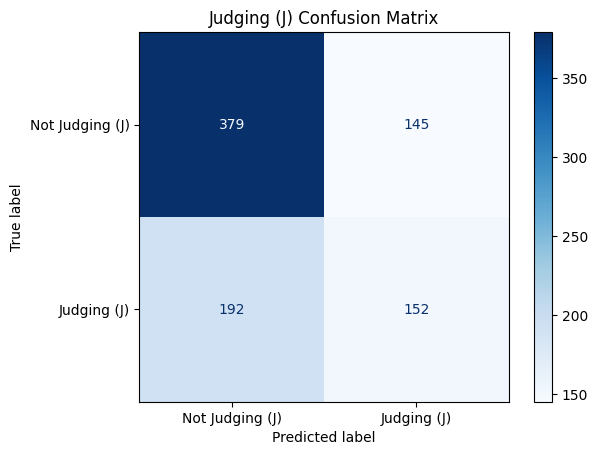

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_and_plot(trainer, val_dataset, title):
    preds_output = trainer.predict(val_dataset)
    y_pred = np.argmax(preds_output.predictions, axis=1)
    y_true = preds_output.label_ids

    # Print classification report
    print(f"\nClassification Report for {title}:")
    print(classification_report(y_true, y_pred, target_names=[f"Not {title}", title], zero_division=0))


    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Not {title}", title])
    disp.plot(cmap='Blues')
    plt.title(f"{title} Confusion Matrix")
    plt.show()

# Evaluate each model
evaluate_and_plot(trainer_ie, val_ds_ie, "Introvert (I)")
evaluate_and_plot(trainer_ns, val_ds_ns, "Intuitive (N)")
evaluate_and_plot(trainer_tf, val_ds_tf, "Thinking (T)")
evaluate_and_plot(trainer_jp, val_ds_jp, "Judging (J)")


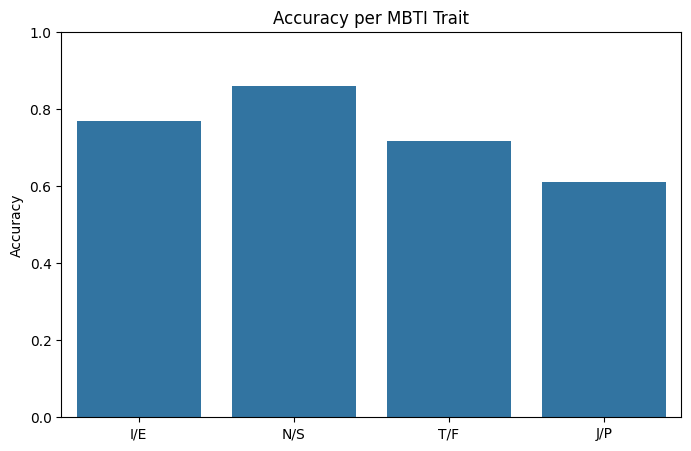

In [ ]:
def get_accuracy(trainer, val_dataset):
    preds_output = trainer.predict(val_dataset)
    y_pred = np.argmax(preds_output.predictions, axis=1)
    y_true = preds_output.label_ids
    return np.mean(y_pred == y_true)

accuracies = {
    "I/E": get_accuracy(trainer_ie, val_ds_ie),
    "N/S": get_accuracy(trainer_ns, val_ds_ns),
    "T/F": get_accuracy(trainer_tf, val_ds_tf),
    "J/P": get_accuracy(trainer_jp, val_ds_jp)
}

# Plot bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy per MBTI Trait")
plt.show()



=== I/E  |  TF-IDF baseline ===
Accuracy: 0.7793
              precision    recall  f1-score   support

           0      0.905     0.048     0.090       400
           1      0.778     0.999     0.874      1335

    accuracy                          0.779      1735
   macro avg      0.841     0.523     0.482      1735
weighted avg      0.807     0.779     0.694      1735



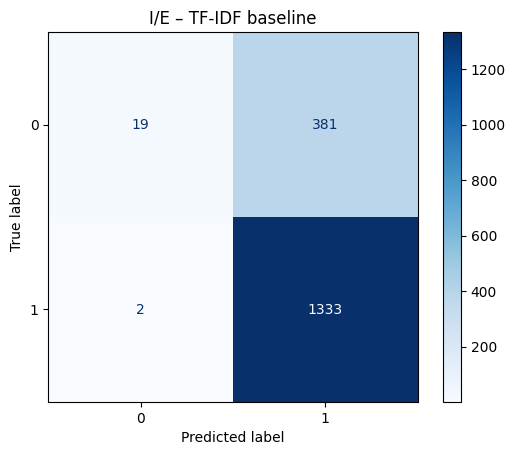


=== N/S  |  TF-IDF baseline ===
Accuracy: 0.8628
              precision    recall  f1-score   support

           0      1.000     0.004     0.008       239
           1      0.863     1.000     0.926      1496

    accuracy                          0.863      1735
   macro avg      0.931     0.502     0.467      1735
weighted avg      0.882     0.863     0.800      1735



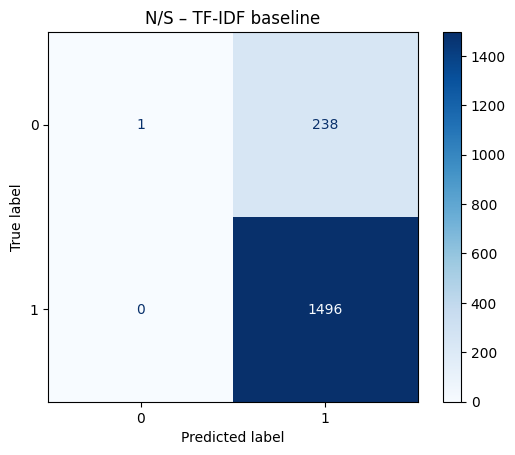


=== T/F  |  TF-IDF baseline ===
Accuracy: 0.7954
              precision    recall  f1-score   support

           0      0.805     0.820     0.813       939
           1      0.783     0.766     0.775       796

    accuracy                          0.795      1735
   macro avg      0.794     0.793     0.794      1735
weighted avg      0.795     0.795     0.795      1735



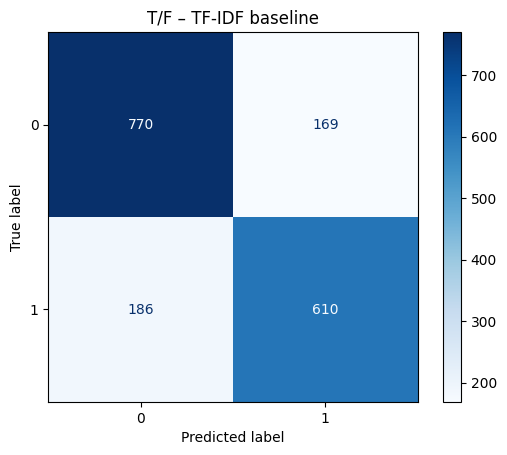


=== J/P  |  TF-IDF baseline ===
Accuracy: 0.6813
              precision    recall  f1-score   support

           0      0.677     0.902     0.774      1048
           1      0.697     0.345     0.462       687

    accuracy                          0.681      1735
   macro avg      0.687     0.623     0.618      1735
weighted avg      0.685     0.681     0.650      1735



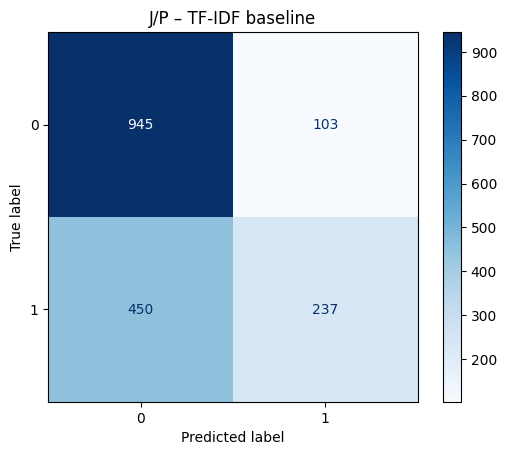

,BERT,TF-IDF
I/E,0.769585,0.779251
N/S,0.861751,0.862824
T/F,0.716590,0.795389
J/P,0.611751,0.681268


In [ ]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

def run_tfidf_baseline(df, target, test_size=0.2, random_state=42):
    """Return accuracy and fitted pipeline for one MBTI binary target."""
    X_train, X_val, y_train, y_val = train_test_split(
        df["posts"], df[target],
        test_size=test_size, stratify=df[target], random_state=random_state
    )

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),        # unigrams + bigrams
            max_features=30_000
        )),
        ("clf", LogisticRegression(
            max_iter=2_000,
            n_jobs=-1,                 # speed-up on multi-core
            solver="lbfgs"
        ))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)

    # Metrics ----------------------------------------------------------------
    acc = accuracy_score(y_val, y_pred)
    print(f"\n=== {target}  |  TF-IDF baseline ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_val, y_pred, digits=3))

    # Confusion matrix -------------------------------------------------------
    ConfusionMatrixDisplay(
        confusion_matrix(y_val, y_pred),
        display_labels=["0", "1"]
    ).plot(cmap="Blues", values_format="d")
    plt.title(f"{target} – TF-IDF baseline")
    plt.show()

    return acc, pipe


tfidf_results = {}
for col in ["I/E", "N/S", "T/F", "J/P"]:
    tfidf_results[col], _ = run_tfidf_baseline(mbti_data1, col)

# ---------------------------------------------------------------------------
# Compact scoreboard versus your fine-tuned BERT models
# (assumes you already stored BERT validation accuracy in the dict `bert_acc`)
bert_acc = {
    "I/E": trainer_ie.evaluate()["eval_accuracy"],
    "N/S": trainer_ns.evaluate()["eval_accuracy"],
    "T/F": trainer_tf.evaluate()["eval_accuracy"],
    "J/P": trainer_jp.evaluate()["eval_accuracy"],
}

import pandas as pd
pd.DataFrame({"BERT": bert_acc, "TF-IDF": tfidf_results})